In [1]:
import json, os, sys, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.stats import wilcoxon
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

INSTANCES  = ['eil51', 'kroA100', 'ch150']
ALGORITHMS = ['RL-AGA', 'NSGA2', 'MOEAD', 'GA-Static', 'GA-Random']
ALG_LABELS = {
    'RL-AGA'   : 'RL-AGA (ours)',
    'NSGA2'    : 'NSGA-II',
    'MOEAD'    : 'MOEA/D',
    'GA-Static': 'GA-Static',
    'GA-Random': 'GA-Random'
}
ALG_COLORS = {
    'RL-AGA'   : '#1f77b4',
    'NSGA2'    : '#ff7f0e',
    'MOEAD'    : '#2ca02c',
    'GA-Static': '#d62728',
    'GA-Random': '#9467bd'
}
os.makedirs('paper_tables', exist_ok=True)

# Load all results
results = {}
for inst in INSTANCES:
    results[inst] = {}
    for alg in ALGORITHMS:
        results[inst][alg] = json.load(
            open(f'results/{inst}_{alg}.json', encoding='utf-8'))

# Load Phase 5 metrics (HV, IGD) — recompute for consistency
from pymoo.indicators.hv  import HV
from pymoo.indicators.igd import IGD

# Global bounds
global_bounds = {}
for inst in INSTANCES:
    all_pts = []
    for alg in ALGORITHMS:
        for run in results[inst][alg]:
            if run['archive_objs']:
                all_pts.extend(run['archive_objs'])
    all_pts = np.array(all_pts)
    global_bounds[inst] = {'min': all_pts.min(0), 'max': all_pts.max(0)}

def norm_pts(pts, inst):
    pts  = np.array(pts)
    lo   = global_bounds[inst]['min']
    hi   = global_bounds[inst]['max']
    denom = np.where(hi - lo < 1e-10, 1.0, hi - lo)
    return (pts - lo) / denom

# Reference fronts
def get_nd(points):
    pts = np.array(points)
    keep = []
    for i, p in enumerate(pts):
        others = np.delete(pts, i, axis=0)
        if not any(np.all(o <= p) and np.any(o < p) for o in others):
            keep.append(p)
    return np.array(keep) if keep else pts[:1]

ref_fronts, metrics = {}, {}
HV_REF = np.array([1.1, 1.1, 1.1])

for inst in INSTANCES:
    all_norm = []
    for alg in ALGORITHMS:
        for run in results[inst][alg]:
            if run['archive_objs']:
                all_norm.extend(norm_pts(run['archive_objs'], inst).tolist())
    ref_fronts[inst] = get_nd(np.array(all_norm))

    metrics[inst] = {}
    hv_ind  = HV(ref_point=HV_REF)
    igd_ind = IGD(ref_fronts[inst])
    for alg in ALGORITHMS:
        hvs, igds, times = [], [], []
        for run in results[inst][alg]:
            if run['archive_objs']:
                F = np.clip(norm_pts(run['archive_objs'], inst), 0, 1.05)
                hvs.append(float(hv_ind(F)))
                igds.append(float(igd_ind(F)))
                times.append(run['runtime_s'])
        metrics[inst][alg] = {
            'hv': np.array(hvs), 'igd': np.array(igds),
            'time': np.array(times)
        }

print('Data loaded. Phase 5b ready.')

Data loaded. Phase 5b ready.


In [2]:
# ── Spacing metric ─────────────────────────────────────────────────────────────
def spacing(front):
    """Uniformity of Pareto front. Lower = more evenly distributed."""
    F = np.array(front)
    if len(F) < 2:
        return 0.0
    d = []
    for i in range(len(F)):
        dists = np.linalg.norm(F - F[i], axis=1)
        dists[i] = np.inf
        d.append(dists.min())
    d = np.array(d)
    return float(np.sqrt(np.sum((d - d.mean())**2) / (len(d) - 1)))

# ── C-metric (Coverage) ────────────────────────────────────────────────────────
def c_metric(A, B):
    """
    C(A, B) = fraction of B's solutions weakly dominated by >= 1 solution in A.
    C(A, B) = 1 → A completely covers B.
    """
    if len(A) == 0 or len(B) == 0:
        return 0.0
    A, B = np.array(A), np.array(B)
    count = sum(
        1 for b in B
        if any(np.all(a <= b) and np.any(a < b) for a in A)
    )
    return count / len(B)

# ── Compute all new metrics for every run ─────────────────────────────────────
ext_metrics = {}

for inst in INSTANCES:
    ext_metrics[inst] = {}
    for alg in ALGORITHMS:
        sp_list, hve_list, c_vs_rl = [], [], []
        for run in results[inst][alg]:
            if run['archive_objs']:
                F_norm = norm_pts(run['archive_objs'], inst)
                sp_list.append(spacing(F_norm))
                hv_val  = metrics[inst][alg]['hv'][
                    results[inst][alg].index(run)
                    if run in results[inst][alg] else 0]

        # Recompute per-run HV, Spacing, HVE
        sps, hves, raws = [], [], []
        hv_ind = HV(ref_point=HV_REF)
        for run in results[inst][alg]:
            if run['archive_objs']:
                F_norm = np.clip(norm_pts(run['archive_objs'], inst), 0, 1.05)
                hv_val = float(hv_ind(F_norm))
                sps.append(spacing(F_norm))
                hves.append(hv_val / max(run['runtime_s'], 0.1))
                raws.append(run['archive_objs'])

        ext_metrics[inst][alg] = {
            'sp'  : np.array(sps),
            'hve' : np.array(hves),   # HV / second
            'raw' : raws
        }

# ── C-metric matrix (mean over 20 runs) ───────────────────────────────────────
c_matrix = {}   # c_matrix[inst][A][B] = mean C(A_archive, B_archive)

for inst in INSTANCES:
    c_matrix[inst] = {}
    for alg_a in ALGORITHMS:
        c_matrix[inst][alg_a] = {}
        for alg_b in ALGORITHMS:
            vals = []
            data_a = results[inst][alg_a]
            data_b = results[inst][alg_b]
            for i in range(min(len(data_a), len(data_b))):
                if data_a[i]['archive_objs'] and data_b[i]['archive_objs']:
                    A = norm_pts(data_a[i]['archive_objs'], inst)
                    B = norm_pts(data_b[i]['archive_objs'], inst)
                    vals.append(c_metric(A, B))
            c_matrix[inst][alg_a][alg_b] = np.mean(vals) if vals else 0.0

# ── Consistency Index = 1 - CV ────────────────────────────────────────────────
print(f'\n{"":30} {"SP mean":>10} {"HVE mean":>10} {"CI(HV)":>10}')
print('-' * 65)
for inst in INSTANCES:
    print(f'--- {inst} ---')
    for alg in ALGORITHMS:
        m   = metrics[inst][alg]
        sp  = ext_metrics[inst][alg]['sp'].mean()
        hve = ext_metrics[inst][alg]['hve'].mean()
        ci  = 1 - (m['hv'].std() / (m['hv'].mean() + 1e-10))
        print(f'  {alg:<26} {sp:>10.4f} {hve:>10.4f} {ci:>10.4f}')
    print()


                                  SP mean   HVE mean     CI(HV)
-----------------------------------------------------------------
--- eil51 ---
  RL-AGA                         0.0232     0.0181     0.9016
  NSGA2                          0.0106     0.0043     0.9000
  MOEAD                          0.0366     0.0230     0.9487
  GA-Static                      0.0384     0.0225     0.9345
  GA-Random                      0.0221     0.0199     0.9335

--- kroA100 ---
  RL-AGA                         0.0143     0.0199     0.8133
  NSGA2                          0.0090     0.0021     0.5802
  MOEAD                          0.0183     0.0176     0.7805
  GA-Static                      0.0175     0.0219     0.7736
  GA-Random                      0.0142     0.0215     0.8865

--- ch150 ---
  RL-AGA                         0.0162     0.0103     0.9082
  NSGA2                          0.0071     0.0016     0.4501
  MOEAD                          0.0283     0.0137     0.8793
  GA-Static      

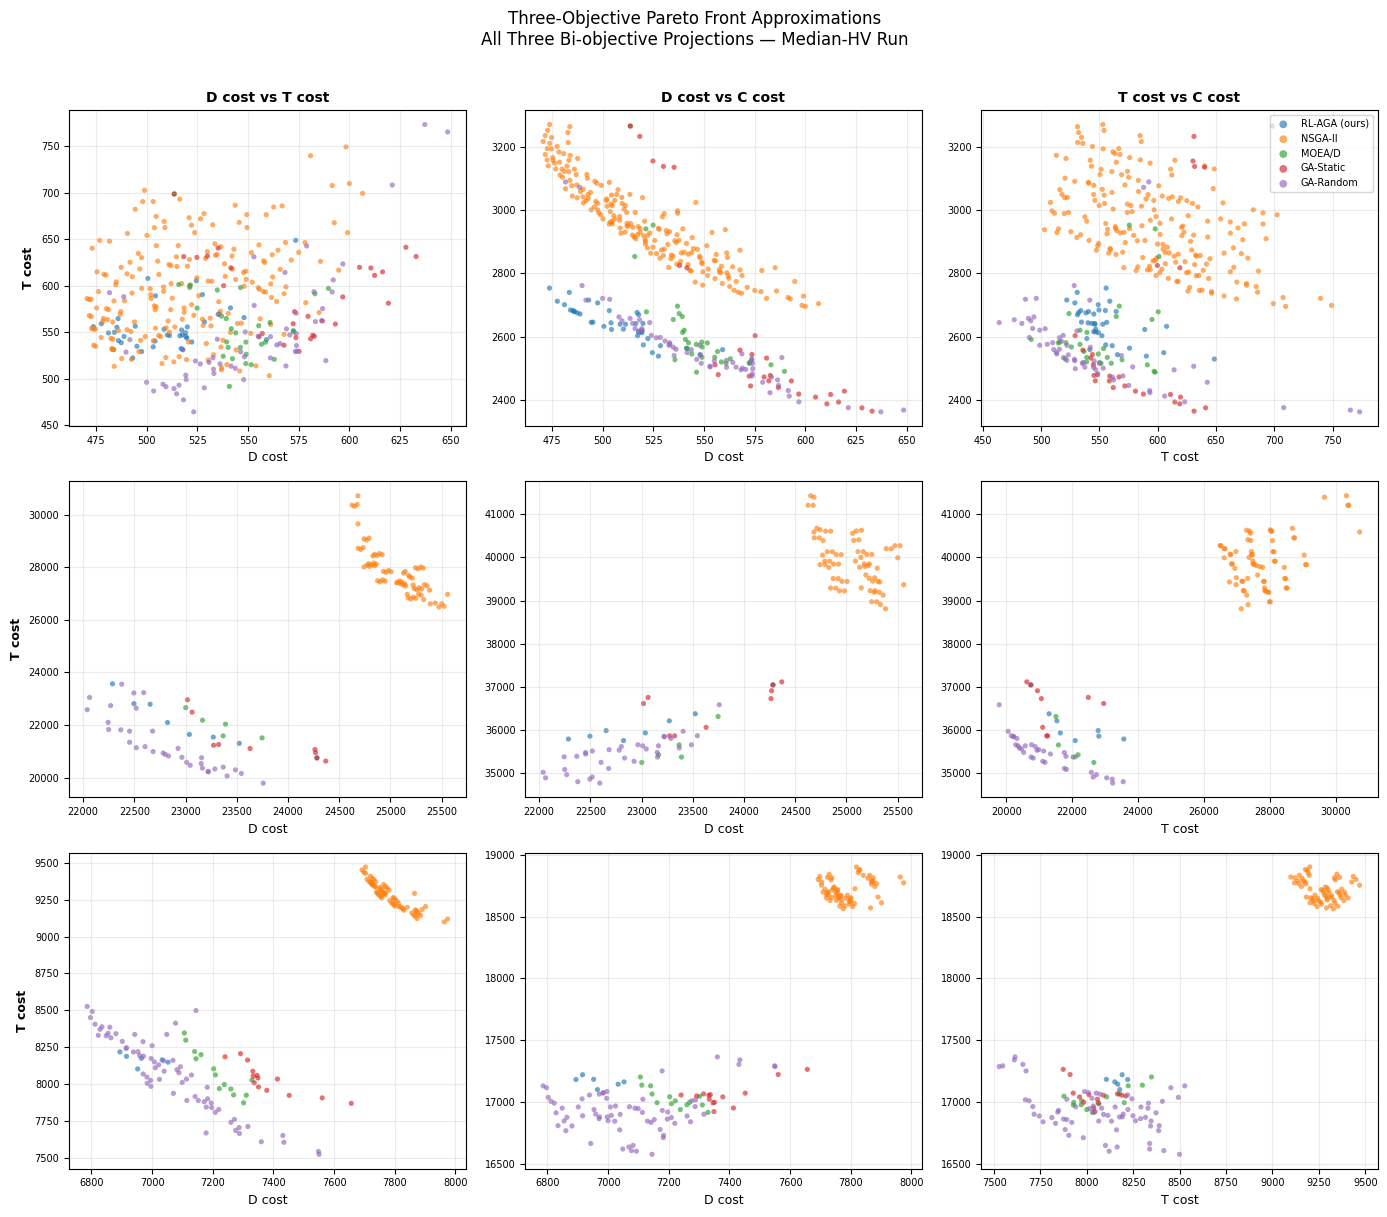

Figure 5 saved.


In [3]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

projections = [(0, 1, 'D cost', 'T cost'),
               (0, 2, 'D cost', 'C cost'),
               (1, 2, 'T cost', 'C cost')]

for row, inst in enumerate(INSTANCES):
    for col, (xi, yi, xlabel, ylabel) in enumerate(projections):
        ax = axes[row, col]

        for alg in ALGORITHMS:
            hv_vals = metrics[inst][alg]['hv']
            med_idx = np.argsort(hv_vals)[len(hv_vals)//2]
            run     = results[inst][alg][med_idx]
            if not run['archive_objs']:
                continue
            F = np.array(run['archive_objs'])
            ax.scatter(F[:, xi], F[:, yi],
                       c=ALG_COLORS[alg],
                       label=ALG_LABELS[alg],
                       s=14, alpha=0.65, edgecolors='none')

        if col == 0:
            ax.set_ylabel(inst, fontsize=11, fontweight='bold')
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(ylabel if col == 0 else '', fontsize=9)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.25)
        if row == 0 and col == 2:
            ax.legend(fontsize=7, loc='upper right',
                      markerscale=1.5, framealpha=0.8)

        # Axis label at top of each column
        if row == 0:
            ax.set_title(f'{xlabel} vs {ylabel}',
                         fontsize=10, fontweight='bold')

plt.suptitle('Three-Objective Pareto Front Approximations\n'
             'All Three Bi-objective Projections — Median-HV Run',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('paper_tables/fig5_3d_pareto_projections.pdf',
            bbox_inches='tight', dpi=300)
plt.show()
print('Figure 5 saved.')

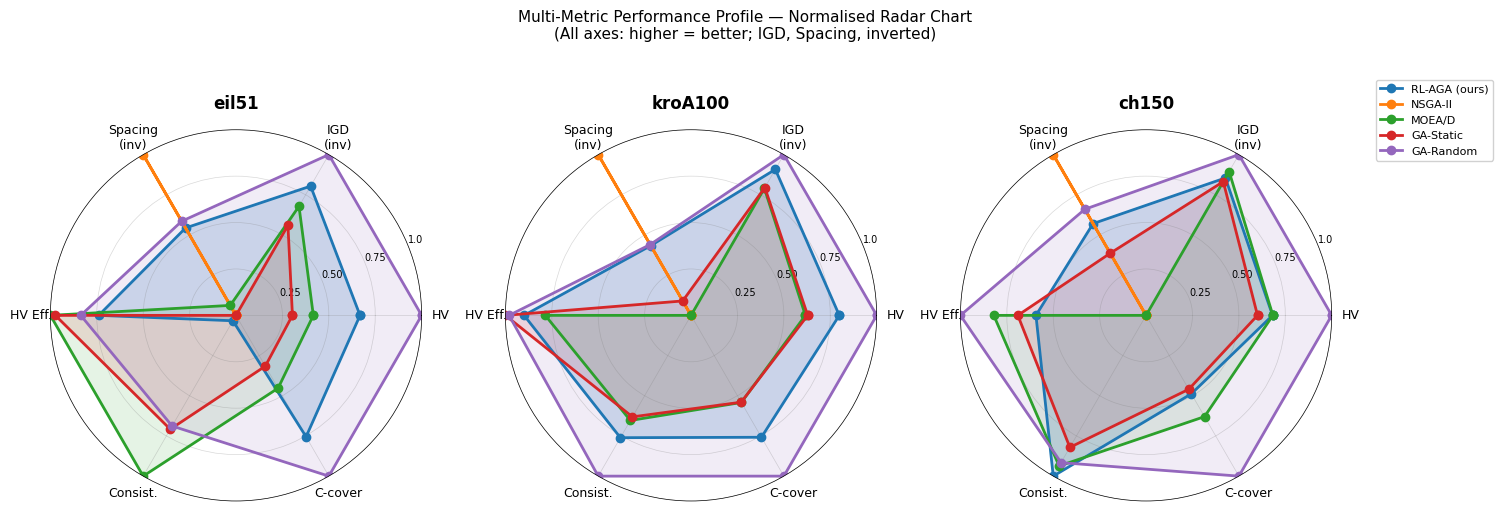

Figure 6 saved.


In [4]:
from matplotlib.patches import FancyArrowPatch

def make_radar(ax, values, color, label, alpha=0.15):
    N = len(values)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    values_plot = values + [values[0]]
    angles      += [angles[0]]
    ax.plot(angles, values_plot, 'o-', color=color, lw=2, label=label)
    ax.fill(angles, values_plot, color=color, alpha=alpha)

metric_labels = ['HV', 'IGD\n(inv)', 'Spacing\n(inv)', 'HV Eff.',
                 'Consist.', 'C-cover']

fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                          subplot_kw=dict(polar=True))

for ax_idx, inst in enumerate(INSTANCES):
    ax = axes[ax_idx]
    N  = len(metric_labels)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles_full = angles + [angles[0]]

    # Collect raw metric arrays for normalisation
    raw = {alg: {} for alg in ALGORITHMS}
    for alg in ALGORITHMS:
        m   = metrics[inst][alg]
        sp  = ext_metrics[inst][alg]['sp'].mean()
        hve = ext_metrics[inst][alg]['hve'].mean()
        ci  = 1 - (m['hv'].std() / (m['hv'].mean() + 1e-10))
        # C-coverage: mean C(alg, all others)
        others_c = [c_matrix[inst][alg][b]
                    for b in ALGORITHMS if b != alg]
        c_cov = np.mean(others_c)
        raw[alg] = {
            'hv' : m['hv'].mean(),
            'igd': m['igd'].mean(),
            'sp' : sp,
            'hve': hve,
            'ci' : ci,
            'c'  : c_cov
        }

    # Normalise each metric to [0,1]: higher = better
    keys = ['hv', 'igd', 'sp', 'hve', 'ci', 'c']
    inverts = [False, True, True, False, False, False]
    all_vals = {k: [raw[a][k] for a in ALGORITHMS] for k in keys}
    norm = {}
    for k, inv in zip(keys, inverts):
        mn, mx = min(all_vals[k]), max(all_vals[k])
        span   = mx - mn if mx > mn else 1.0
        if inv:
            norm[k] = {a: 1 - (raw[a][k] - mn)/span for a in ALGORITHMS}
        else:
            norm[k] = {a: (raw[a][k] - mn)/span    for a in ALGORITHMS}

    for alg in ALGORITHMS:
        vals = [norm['hv'][alg], norm['igd'][alg], norm['sp'][alg],
                norm['hve'][alg], norm['ci'][alg], norm['c'][alg]]
        make_radar(ax, vals, ALG_COLORS[alg], ALG_LABELS[alg],
                   alpha=0.12 if alg != 'RL-AGA' else 0.20)

    # Draw grid
    ax.set_xticks(angles)
    ax.set_xticklabels(metric_labels, fontsize=9)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25','0.50','0.75','1.0'], fontsize=7)
    ax.set_ylim(0, 1)
    ax.set_title(inst, fontsize=12, fontweight='bold', pad=15)
    ax.grid(color='gray', alpha=0.3, linewidth=0.5)
    ax.spines['polar'].set_linewidth(0.5)

    if ax_idx == 2:
        ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15),
                  fontsize=8, framealpha=0.9)

plt.suptitle('Multi-Metric Performance Profile — Normalised Radar Chart\n'
             '(All axes: higher = better; IGD, Spacing, inverted)',
             fontsize=11, y=1.04)
plt.tight_layout()
plt.savefig('paper_tables/fig6_radar_chart.pdf',
            bbox_inches='tight', dpi=300)
plt.show()
print('Figure 6 saved.')

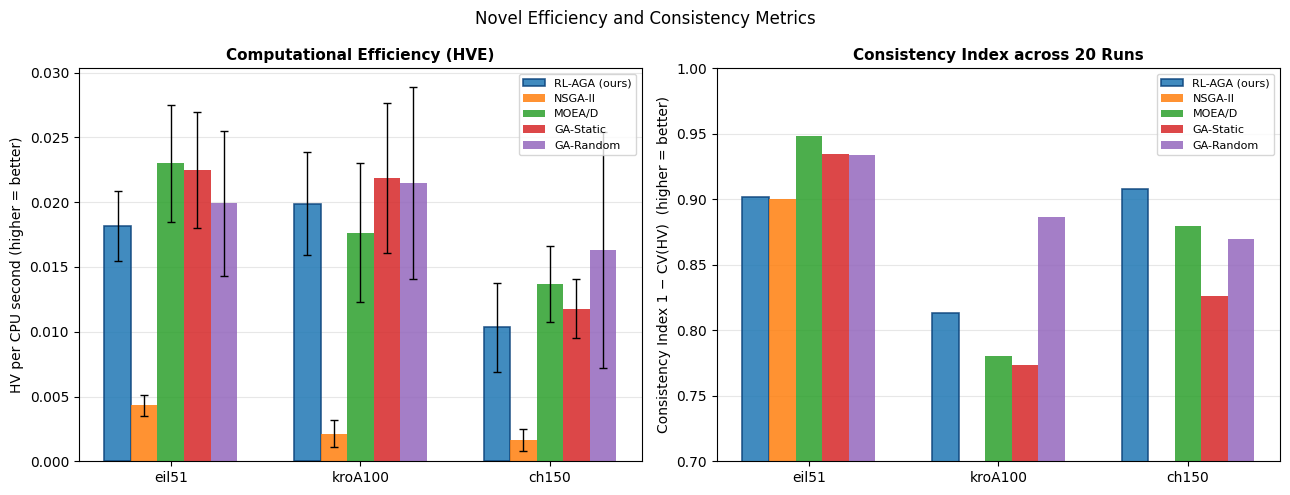

Figure 7 saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x       = np.arange(len(INSTANCES))
n_alg   = len(ALGORITHMS)
w_bar   = 0.14

# Left: HV Efficiency (HV per second)
ax = axes[0]
for i, alg in enumerate(ALGORITHMS):
    hve_vals = [ext_metrics[inst][alg]['hve'].mean() for inst in INSTANCES]
    hve_std  = [ext_metrics[inst][alg]['hve'].std()  for inst in INSTANCES]
    offset   = (i - n_alg/2 + 0.5) * w_bar
    bars = ax.bar(x + offset, hve_vals, w_bar,
                   label=ALG_LABELS[alg],
                   color=ALG_COLORS[alg], alpha=0.85,
                   yerr=hve_std, capsize=3, error_kw={'lw':1})
    if alg == 'RL-AGA':
        for bar in bars:
            bar.set_edgecolor('#0C447C')
            bar.set_linewidth(1.2)

ax.set_xticks(x); ax.set_xticklabels(INSTANCES, fontsize=10)
ax.set_ylabel('HV per CPU second (higher = better)', fontsize=10)
ax.set_title('Computational Efficiency (HVE)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
ax.set_axisbelow(True)

# Right: Consistency Index 1 - CV(HV)
ax = axes[1]
for i, alg in enumerate(ALGORITHMS):
    ci_vals = []
    for inst in INSTANCES:
        m  = metrics[inst][alg]
        ci = 1 - (m['hv'].std() / (m['hv'].mean() + 1e-10))
        ci_vals.append(ci)
    offset = (i - n_alg/2 + 0.5) * w_bar
    bars = ax.bar(x + offset, ci_vals, w_bar,
                   label=ALG_LABELS[alg],
                   color=ALG_COLORS[alg], alpha=0.85)
    if alg == 'RL-AGA':
        for bar in bars:
            bar.set_edgecolor('#0C447C')
            bar.set_linewidth(1.2)

ax.set_xticks(x); ax.set_xticklabels(INSTANCES, fontsize=10)
ax.set_ylabel('Consistency Index 1 − CV(HV)  (higher = better)', fontsize=10)
ax.set_title('Consistency Index across 20 Runs', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylim(0.7, 1.0)
ax.grid(True, axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.suptitle('Novel Efficiency and Consistency Metrics', fontsize=12)
plt.tight_layout()
plt.savefig('paper_tables/fig7_efficiency_consistency.pdf',
            bbox_inches='tight', dpi=300)
plt.show()
print('Figure 7 saved.')

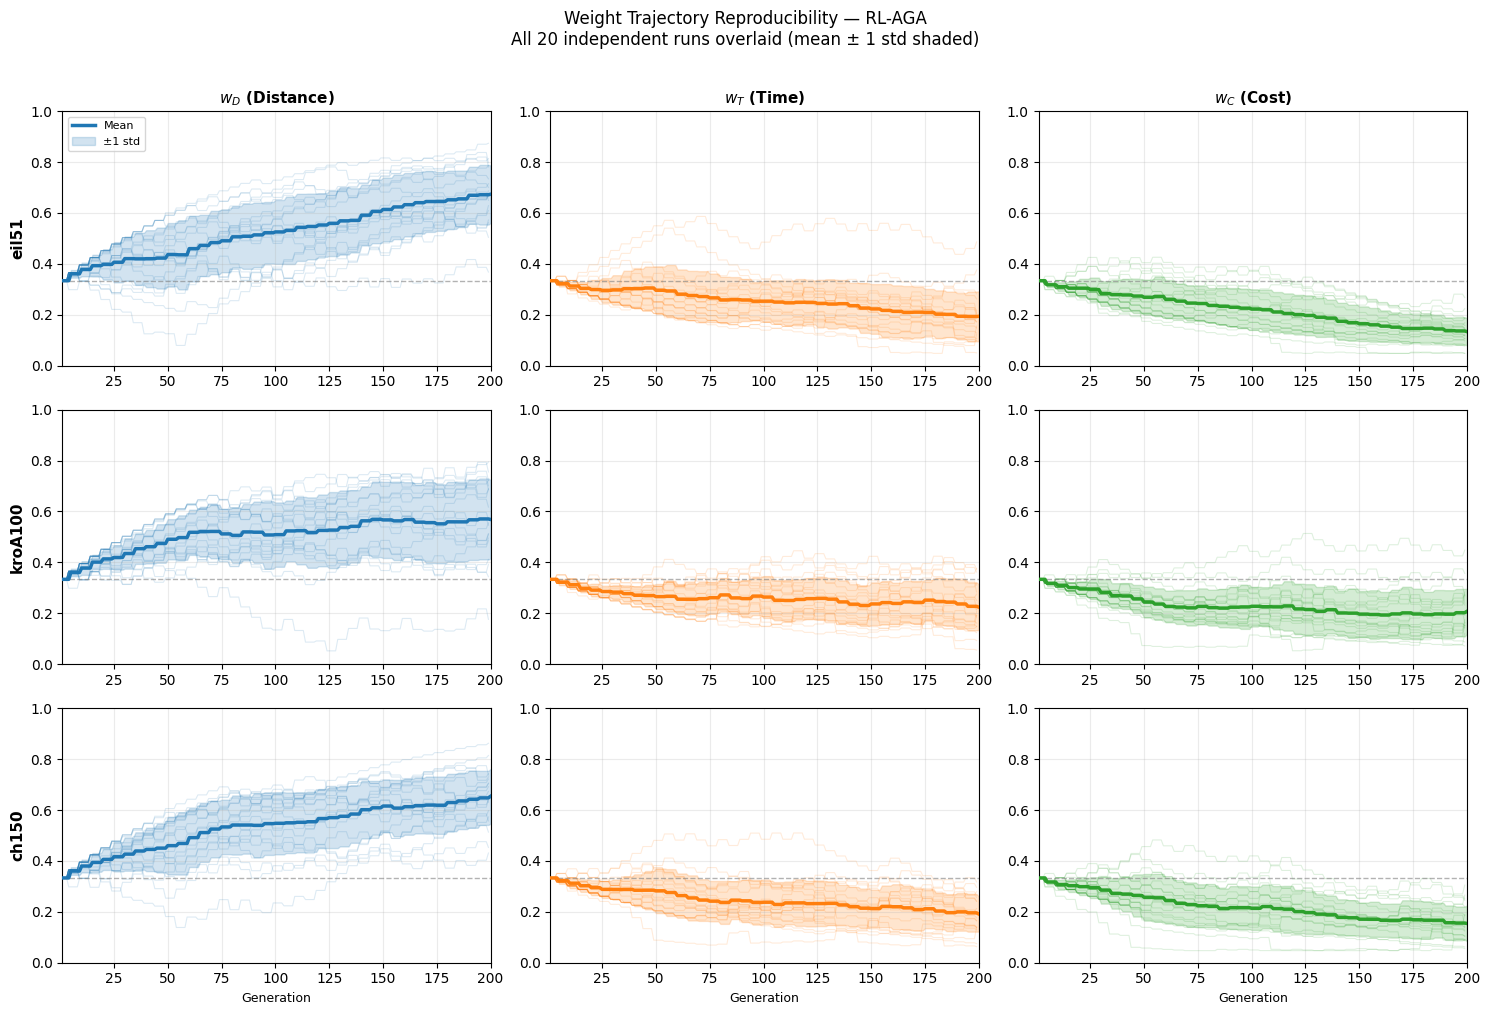

Figure 8 saved.


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
w_keys   = [0, 1, 2]
w_names  = ['$w_D$ (Distance)', '$w_T$ (Time)', '$w_C$ (Cost)']
w_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for row, inst in enumerate(INSTANCES):
    for col, (wk, wn, wc) in enumerate(zip(w_keys, w_names, w_colors)):
        ax = axes[row, col]

        all_trajectories = []
        for run in results[inst]['RL-AGA']:
            if run['log']:
                traj = [entry['w'][wk] for entry in run['log']]
                all_trajectories.append(traj)
                ax.plot(traj, color=wc, alpha=0.15, lw=0.8)

        # Mean and std band
        if all_trajectories:
            mat  = np.array(all_trajectories)
            mean = mat.mean(axis=0)
            std  = mat.std(axis=0)
            gens = np.arange(1, len(mean)+1)
            ax.plot(gens, mean, color=wc, lw=2.5, label='Mean', zorder=5)
            ax.fill_between(gens, mean-std, mean+std,
                            color=wc, alpha=0.2, label='±1 std')

        ax.axhline(1/3, color='gray', ls='--', lw=1, alpha=0.6)
        ax.set_ylim(0, 1)
        ax.set_xlim(1, 200)
        ax.grid(True, alpha=0.25)

        if row == 0:
            ax.set_title(wn, fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(inst, fontsize=11, fontweight='bold')
        if row == 2:
            ax.set_xlabel('Generation', fontsize=9)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Weight Trajectory Reproducibility — RL-AGA\n'
             'All 20 independent runs overlaid (mean ± 1 std shaded)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('paper_tables/fig8_weight_trajectories.pdf',
            bbox_inches='tight', dpi=300)
plt.show()
print('Figure 8 saved.')

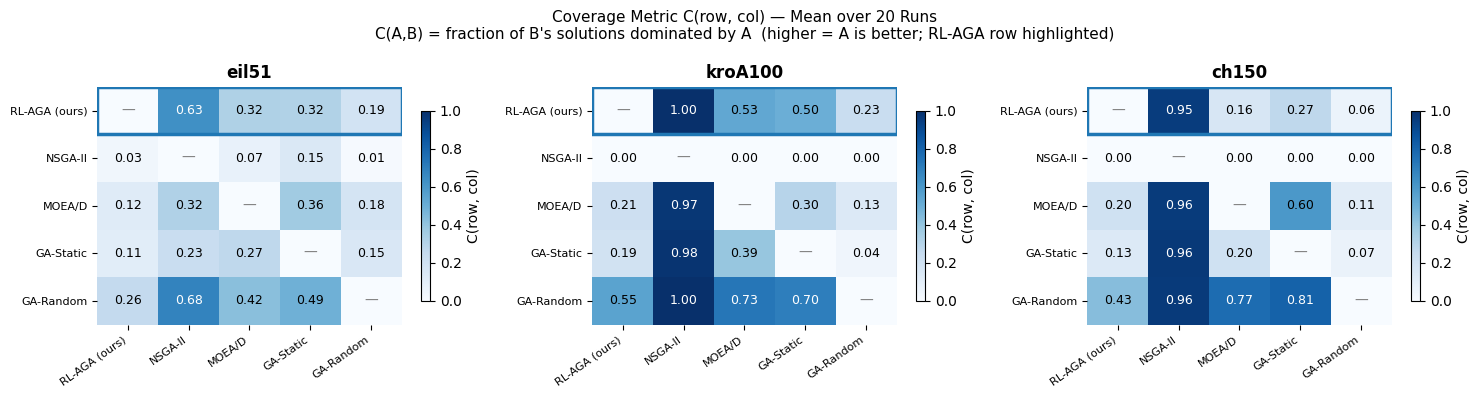

Figure 9 saved.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax_idx, inst in enumerate(INSTANCES):
    ax   = axes[ax_idx]
    mat  = np.zeros((len(ALGORITHMS), len(ALGORITHMS)))

    for i, alg_a in enumerate(ALGORITHMS):
        for j, alg_b in enumerate(ALGORITHMS):
            mat[i, j] = c_matrix[inst][alg_a][alg_b]

    # Mask diagonal
    mask = np.eye(len(ALGORITHMS), dtype=bool)

    im = ax.imshow(mat, cmap='Blues', vmin=0, vmax=1,
                   aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8, label='C(row, col)')

    # Cell annotations
    for i in range(len(ALGORITHMS)):
        for j in range(len(ALGORITHMS)):
            if i == j:
                ax.text(j, i, '—', ha='center', va='center',
                        fontsize=10, color='gray')
            else:
                val   = mat[i, j]
                color = 'white' if val > 0.6 else 'black'
                ax.text(j, i, f'{val:.2f}',
                        ha='center', va='center',
                        fontsize=9, color=color, fontweight='500')

    tick_labels = [ALG_LABELS[a] for a in ALGORITHMS]
    ax.set_xticks(range(len(ALGORITHMS)))
    ax.set_yticks(range(len(ALGORITHMS)))
    ax.set_xticklabels(tick_labels, rotation=35,
                        ha='right', fontsize=8)
    ax.set_yticklabels(tick_labels, fontsize=8)
    ax.set_title(f'{inst}', fontsize=12, fontweight='bold')

    # Highlight RL-AGA row
    rl_idx = ALGORITHMS.index('RL-AGA')
    for spine in ['top','bottom','left','right']:
        ax.spines[spine].set_linewidth(0)
    rect = plt.Rectangle((-0.5, rl_idx - 0.5), len(ALGORITHMS), 1,
                          fill=False, edgecolor='#1f77b4',
                          linewidth=2.5, zorder=10)
    ax.add_patch(rect)

plt.suptitle('Coverage Metric C(row, col) — Mean over 20 Runs\n'
             'C(A,B) = fraction of B\'s solutions dominated by A  '
             '(higher = A is better; RL-AGA row highlighted)',
             fontsize=11)
plt.tight_layout()
plt.savefig('paper_tables/fig9_coverage_heatmap.pdf',
            bbox_inches='tight', dpi=300)
plt.show()
print('Figure 9 saved.')

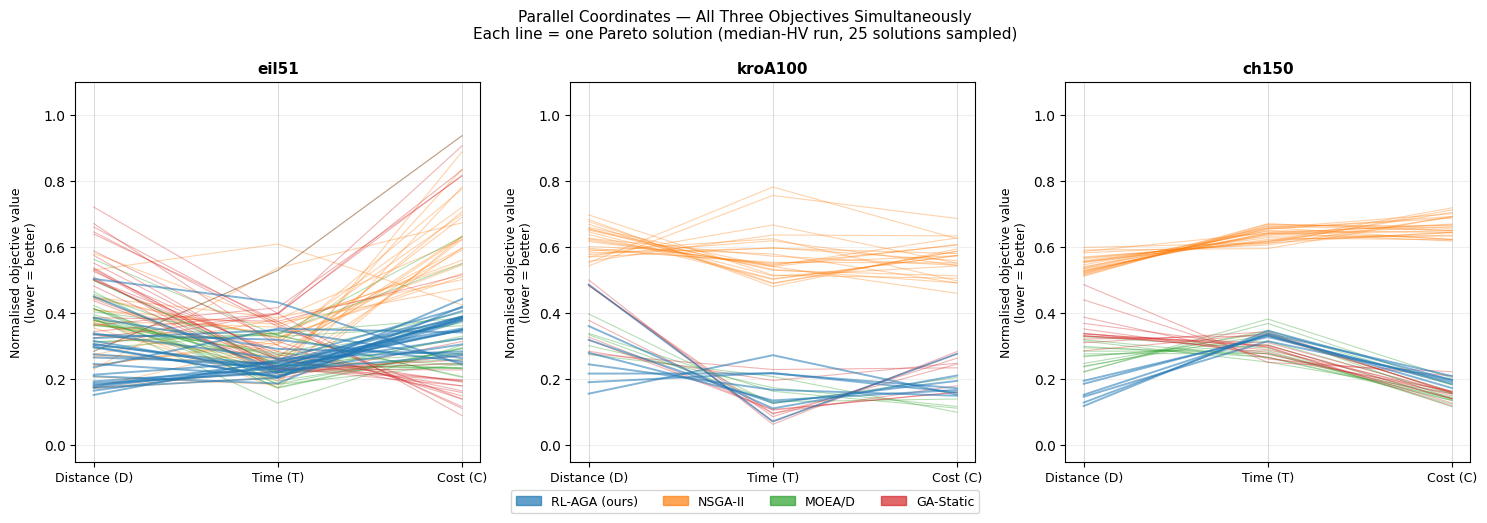

Figure 10 saved.


In [8]:
from matplotlib.path import Path
import matplotlib.patches as patches

def parallel_coords(ax, data_dict, inst, n_lines=30):
    """
    data_dict: {alg: array of shape (n_solutions, 3)}
    """
    obj_names = ['Distance (D)', 'Time (T)', 'Cost (C)']
    n_obj     = 3

    # Normalise to [0,1] for display using global bounds
    lo = global_bounds[inst]['min']
    hi = global_bounds[inst]['max']
    span = np.where(hi - lo < 1e-10, 1.0, hi - lo)

    # Draw gridlines
    for j in range(n_obj):
        ax.axvline(j, color='gray', lw=0.5, alpha=0.4)

    # Plot each algorithm's solutions
    for alg in ['NSGA2', 'MOEAD', 'GA-Static', 'RL-AGA']:
        hv_vals = metrics[inst][alg]['hv']
        med_idx = np.argsort(hv_vals)[len(hv_vals)//2]
        run     = results[inst][alg][med_idx]
        if not run['archive_objs']:
            continue

        F    = np.array(run['archive_objs'])
        F_n  = (F - lo) / span          # normalised

        # Sample up to n_lines solutions
        idx  = np.random.choice(len(F_n),
                                 min(n_lines, len(F_n)),
                                 replace=False)
        alpha = 0.35 if alg != 'RL-AGA' else 0.55
        lw    = 0.8  if alg != 'RL-AGA' else 1.4

        for i in idx:
            ys = F_n[i]
            ax.plot(range(n_obj), ys,
                    color=ALG_COLORS[alg], alpha=alpha, lw=lw)

    ax.set_xticks(range(n_obj))
    ax.set_xticklabels(obj_names, fontsize=9)
    ax.set_ylabel('Normalised objective value\n(lower = better)',
                  fontsize=9)
    ax.set_ylim(-0.05, 1.1)
    ax.set_title(inst, fontsize=11, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax_idx, inst in enumerate(INSTANCES):
    np.random.seed(42)
    parallel_coords(axes[ax_idx], None, inst, n_lines=25)

# Legend
handles = [mpatches.Patch(color=ALG_COLORS[a],
                            label=ALG_LABELS[a],
                            alpha=0.7)
           for a in ['RL-AGA', 'NSGA2', 'MOEAD', 'GA-Static']]
fig.legend(handles=handles, loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.suptitle('Parallel Coordinates — All Three Objectives Simultaneously\n'
             'Each line = one Pareto solution (median-HV run, 25 solutions sampled)',
             fontsize=11)
plt.tight_layout()
plt.savefig('paper_tables/fig10_parallel_coords.pdf',
            bbox_inches='tight', dpi=300)
plt.show()
print('Figure 10 saved.')

In [9]:
def make_ext_table():
    hv_ind = HV(ref_point=HV_REF)
    lines  = []
    lines.append(r'% Extended metrics table — paste into Section V-B')
    lines.append(r'\begin{table*}[t]')
    lines.append(r'  \caption{Extended Performance Metrics — '
                 r'Spacing (SP), HV Efficiency (HVE), '
                 r'Consistency Index (CI), and Coverage Metric C(RL-AGA, $\cdot$)}')
    lines.append(r'  \label{tab:extended_metrics}')
    lines.append(r'  \centering')
    lines.append(r'  \renewcommand{\arraystretch}{1.15}')
    lines.append(r'  \begin{tabular}{ll'
                 r'S[table-format=1.4]'
                 r'S[table-format=1.4]'
                 r'S[table-format=1.4]'
                 r'S[table-format=1.4]}')
    lines.append(r'    \hline')
    lines.append(r'    \textbf{Instance} & \textbf{Algorithm} &'
                 r' \textbf{SP$\downarrow$} &'
                 r' \textbf{HVE$\uparrow$} &'
                 r' \textbf{CI$\uparrow$} &'
                 r' \textbf{C(RL-AGA,$\cdot$)$\uparrow$} \\')
    lines.append(r'    \hline')

    for inst in INSTANCES:
        first = True
        for alg in ALGORITHMS:
            m   = metrics[inst][alg]
            sp  = ext_metrics[inst][alg]['sp'].mean()
            hve = ext_metrics[inst][alg]['hve'].mean()
            ci  = 1 - (m['hv'].std() / (m['hv'].mean() + 1e-10))
            c_rl = (c_matrix[inst]['RL-AGA'][alg]
                    if alg != 'RL-AGA' else np.nan)

            inst_col = (r'\multirow{5}{*}{' + inst + r'}') if first else ''
            first    = False

            alg_col = (r'\textbf{' + ALG_LABELS[alg] + r'}')  \
                      if alg == 'RL-AGA' else ALG_LABELS[alg]

            # Find best per column per instance
            c_str = f'{c_rl:.4f}' if not np.isnan(c_rl) else '{---}'

            lines.append(f'    {inst_col} & {alg_col} & '
                         f'{sp:.4f} & {hve:.4f} & {ci:.4f} & {c_str} \\\\')

        lines.append(r'    \hline')

    lines.append(r'  \end{tabular}')
    lines.append(r'  \\[3pt]')
    lines.append(r'  \footnotesize{SP: spacing (lower = more uniform); '
                 r'HVE: HV per CPU second; '
                 r'CI: consistency index $1-\text{CV}(\text{HV})$; '
                 r'C(RL-AGA,$\cdot$): fraction of baseline solutions '
                 r'dominated by RL-AGA (1.0 = complete coverage).}')
    lines.append(r'\end{table*}')
    return '\n'.join(lines)

tex = make_ext_table()
with open('paper_tables/extended_metrics_table.tex', 'w',
          encoding='utf-8') as f:
    f.write(tex)

print('Extended metrics table saved.')
print()
# Print preview of key numbers
print('Key finding — HV Efficiency (HVE):')
for inst in INSTANCES:
    print(f'  {inst}:')
    for alg in ALGORITHMS:
        hve = ext_metrics[inst][alg]['hve'].mean()
        print(f'    {alg:<14}: {hve:.4f} HV/s')

print('\nKey finding — C(RL-AGA, NSGA-II):')
for inst in INSTANCES:
    v = c_matrix[inst]['RL-AGA']['NSGA2']
    print(f'  {inst}: {v:.3f} '
          f'({v*100:.0f}% of NSGA-II solutions dominated by RL-AGA)')

Extended metrics table saved.

Key finding — HV Efficiency (HVE):
  eil51:
    RL-AGA        : 0.0181 HV/s
    NSGA2         : 0.0043 HV/s
    MOEAD         : 0.0230 HV/s
    GA-Static     : 0.0225 HV/s
    GA-Random     : 0.0199 HV/s
  kroA100:
    RL-AGA        : 0.0199 HV/s
    NSGA2         : 0.0021 HV/s
    MOEAD         : 0.0176 HV/s
    GA-Static     : 0.0219 HV/s
    GA-Random     : 0.0215 HV/s
  ch150:
    RL-AGA        : 0.0103 HV/s
    NSGA2         : 0.0016 HV/s
    MOEAD         : 0.0137 HV/s
    GA-Static     : 0.0118 HV/s
    GA-Random     : 0.0163 HV/s

Key finding — C(RL-AGA, NSGA-II):
  eil51: 0.632 (63% of NSGA-II solutions dominated by RL-AGA)
  kroA100: 1.000 (100% of NSGA-II solutions dominated by RL-AGA)
  ch150: 0.951 (95% of NSGA-II solutions dominated by RL-AGA)


In [10]:
print('All Phase 5b files generated:\n')
for f in sorted(os.listdir('paper_tables')):
    if f.endswith('.pdf') or f.endswith('.tex'):
        size = os.path.getsize(f'paper_tables/{f}')
        tag  = ''
        if 'fig5' in f: tag = '← NEW: 3 projections Pareto'
        if 'fig6' in f: tag = '← NEW: radar multi-metric'
        if 'fig7' in f: tag = '← NEW: HVE + consistency'
        if 'fig8' in f: tag = '← NEW: weight reproducibility'
        if 'fig9' in f: tag = '← NEW: C-metric heatmap'
        if 'fig10' in f: tag = '← NEW: parallel coordinates'
        if 'extended' in f: tag = '← NEW: Table 5'
        print(f'  {f:<45} {size//1024:>4}KB  {tag}')

All Phase 5b files generated:

  city_maps.pdf                                   20KB  
  extended_metrics_table.tex                       1KB  ← NEW: Table 5
  fig10_parallel_coords.pdf                       28KB  ← NEW: parallel coordinates
  fig1_archive_growth.pdf                         83KB  
  fig1_convergence.pdf                            77KB  
  fig2_pareto_fronts.pdf                          39KB  
  fig3_weight_evolution.pdf                       34KB  
  fig4_boxplots.pdf                               33KB  
  fig5_3d_pareto_projections.pdf                  68KB  ← NEW: 3 projections Pareto
  fig6_radar_chart.pdf                            37KB  ← NEW: radar multi-metric
  fig7_efficiency_consistency.pdf                 30KB  ← NEW: HVE + consistency
  fig8_weight_trajectories.pdf                   127KB  ← NEW: weight reproducibility
  fig9_coverage_heatmap.pdf                       39KB  ← NEW: C-metric heatmap
  phase2_convergence_test.pdf                     13KB  
  